# Treino LSTM - CHiME6 (ASR Front-End)

Objetivo: treinar um classificador temporal (fala vs ruido/silencio) para servir de pre-processador ao ASR.

Regras deste notebook:
- Sem shuffle temporal de linhas
- Busca de hiperparametros com amostragem temporal contigua
- `dev` para treino/otimizacao
- `eval` dividido temporalmente em duas metades: `evaluation` e `test`

## Imports

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import torch
import optuna
import optuna.visualization as optuna_vis

from chime_lstm_data import (
    load_feature_csv,
    detect_feature_columns,
    temporal_split_by_group,
    split_eval_half_timeline,
    contiguous_subsample_by_group,
    build_sequences,
)
from lstm_model import (
    LSTMClassifier,
    train_sequence_model,
    infer_records, evaluate_model,
    compute_class_weights,
    save_model, load_model,
    compute_metrics,
)

d:\programming\26.1\IAP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configs

In [22]:
BASE_DIR = Path('.')
DEV_CSV = BASE_DIR / 'chime6_kinect_dev.csv'
EVAL_CSV = BASE_DIR / 'chime6_kinect_eval.csv'

ARTIFACTS_DIR = BASE_DIR / 'results' / 'lstm_asr'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

HYPERPARAM_SEARCH_DIR = ARTIFACTS_DIR / 'hyperparam_search'
HYPERPARAM_SEARCH_DIR.mkdir(parents=True, exist_ok=True)

TRIALS_CSV_PATH = HYPERPARAM_SEARCH_DIR / 'optuna_trials_0.csv'
BEST_RESULT_PATH = HYPERPARAM_SEARCH_DIR / 'best_result_0.json'
MODEL_PATH = ARTIFACTS_DIR / 'lstm_asr_best.pt'


SEQ_LEN = 100

# Frações temporais
# DEV_TRAIN_RATIO = 0.85
OPTUNA_DEV_FRAC = 0.30

# Busca de hiperparametros
N_TRIALS = 100
OPTUNA_EPOCHS = 100
FINAL_EPOCHS = 1000 # Treino final
OBJECTIVE_METRIC = 'auroc'

# Early stopping
PATIENCE = 25
MIN_DELTA = 1e-4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 0. Tabela-resumo dos parâmetros do projeto

### Parâmetros que podem ser variados fora da Optuna

| Bloco | Parâmetro | Onde ajustar | Observação |
|---|---:|---|---|
| Janela temporal | `SEQ_LEN` | célula de configuração | Comprimento da sequência enviada ao LSTM |
| Split treino/val | `DEV_TRAIN_RATIO` | célula de configuração | Fração temporal usada no split do `dev` |
| Subamostragem Optuna | `OPTUNA_DEV_FRAC` | célula de configuração | Recorte contíguo para acelerar a busca |
| Optuna | `N_TRIALS` | célula de configuração | Número de tentativas da busca |
| Optuna | `OPTUNA_EPOCHS` | célula de configuração | Épocas por trial |
| Treino final | `FINAL_EPOCHS` | célula de configuração | Épocas do treino final |
| Early stopping | `PATIENCE` | célula de configuração | Paciência baseada em `val_loss` |
| Early stopping | `MIN_DELTA` | célula de configuração | Melhoria mínima considerada relevante |
| Modelo | `batch_norm` | `lstm_model.py` e instância do modelo | Liga/desliga BatchNorm no LSTM |
| Modelo | `output_dim` | instância do modelo | Saída binária compatível com `BCEWithLogitsLoss` |
| Dados | `label_mode` | chamada de `build_sequences` | Many-to-one usando o último frame |
| Otimização | `OBJECTIVE_METRIC` | célula de configuração | Métrica usada na Optuna |

### Especificação do dataset e do modelo

| Item | Especificação | Onde aparece | Observação |
|---|---|---|---|
| Fonte dos dados | CSVs do pipeline CHiME6 | `chime6_pds_pipeline.ipynb` | Base temporal já tabulada |
| Hop temporal | `8 ms` | notebook do pipeline | Cada linha representa um hop |
| Bloco original | `30 s` | notebook do pipeline | Unidade de agrupamento original |
| Identificador | `sample_id` | CSV | Agrupa sessão, array e bloco |
| Dimensão das features | `132` | notebook do pipeline | `log_mel_*` + `spatial_*` |
| Normalização | Já normalizadas | notebook do pipeline | Não aplicar `StandardScaler` extra |
| Tipo de tarefa | Binária | notebook atual | Fala vs ruído/silêncio |
| Estratégia de rótulo | `last` | `build_sequences` | Janela recebe o rótulo do último frame |
| Saída do modelo | `1 logit` | `LSTMClassifier` | Compatível com `BCEWithLogitsLoss` |
| Loss recomendada | `BCEWithLogitsLoss` | notebook do pipeline | Preferida para a configuração atual |
| Split de validação | Temporal, sem shuffle | notebook atual | Mantém a estrutura temporal |
| Split `eval` | Metades temporais | notebook atual | Divide `evaluation` e `test` |

## 1. Carregar base e criar splits temporais

In [3]:
df_dev = load_feature_csv(str(DEV_CSV))
df_eval_all = load_feature_csv(str(EVAL_CSV))

In [4]:
feature_cols = detect_feature_columns(df_dev)
print('n_features:', len(feature_cols))

# df_train_raw, df_val_raw = temporal_split_by_group(df_dev, train_ratio=DEV_TRAIN_RATIO)
df_train_raw = df_dev.copy()
df_val_raw, df_test_raw = split_eval_half_timeline(df_eval_all)

n_features: 132


In [5]:
print('Rows train/val/test:', len(df_train_raw), len(df_val_raw), len(df_test_raw))
print('Class ratio train:', df_train_raw['label'].mean().round(4))
# print('Class ratio val  :', df_val_raw['label'].mean().round(4))
print('Class ratio eval :', df_val_raw['label'].mean().round(4))
print('Class ratio test :', df_test_raw['label'].mean().round(4))

Rows train/val/test: 1110296 596250 596568
Class ratio train: 0.9507
Class ratio eval : 0.7829
Class ratio test : 0.789


## 2. Escalonamento

> As features do CSV do pipeline CHiME6 já vêm normalizadas (z-score por feature).
> Portanto, não aplicamos `StandardScaler` adicional para evitar dupla normalização.

In [6]:
# Features já normalizadas no pipeline de extração CHiME6.
# Mantemos os dataframes como estão (sem scaling adicional).
df_val = df_val_raw.copy()
df_test = df_test_raw.copy()

## 3. Busca de hiperparametros com amostragem temporal contigua

In [8]:
def seq_len_feedback_for_optuna(
    optuna_dev_frac,
    seq_len,
    df_train_base,
    df_val_base,
    group_col='sample_id',
    top_k=10,
    return_all=False,
    min_seq_len=2,
):
    """
    Retorna feedback de viabilidade de seq_len para uma fracão usada no subsample da Optuna.

    Regras:
    - Para gerar ao menos 1 janela por grupo, precisamos de len(grupo_subsample) >= seq_len.
    - len(grupo_subsample) ~= floor(len(grupo_base) * optuna_dev_frac).
    - Limite seguro global usa o menor grupo entre train/val.
    """
    if not (0 < float(optuna_dev_frac) <= 1.0):
        raise ValueError('optuna_dev_frac deve estar no intervalo (0, 1].')

    train_group_sizes = df_train_base.groupby(group_col).size()
    val_group_sizes = df_val_base.groupby(group_col).size()

    min_group_train = int(train_group_sizes.min())
    min_group_val = int(val_group_sizes.min())

    max_train = int(min_group_train * float(optuna_dev_frac))
    max_val = int(min_group_val * float(optuna_dev_frac))
    max_seq_len_possible = min(max_train, max_val)

    if max_seq_len_possible < min_seq_len:
        possible_values = []
    else:
        possible_values = list(range(min_seq_len, max_seq_len_possible + 1))

    if possible_values:
        nearest = sorted(possible_values, key=lambda x: (abs(x - int(seq_len)), -x))[:top_k]
    else:
        nearest = []

    return {
        'requested_seq_len': int(seq_len),
        'optuna_dev_frac': float(optuna_dev_frac),
        'min_group_train_rows': min_group_train,
        'min_group_val_rows': min_group_val,
        'max_seq_len_possible': int(max_seq_len_possible),
        'is_requested_valid': int(seq_len) in set(possible_values),
        'nearest_seq_len_candidates': nearest,
        'all_seq_len_possible': possible_values if return_all else None,
    }

In [17]:
df_train_opt = contiguous_subsample_by_group(df_train_raw, frac=OPTUNA_DEV_FRAC, from_start=True)
df_val_opt = contiguous_subsample_by_group(df_val_raw, frac=OPTUNA_DEV_FRAC, from_start=True)

print('Optuna rows train/val:', len(df_train_opt), len(df_val_opt))

feedback = seq_len_feedback_for_optuna(
    optuna_dev_frac=OPTUNA_DEV_FRAC,
    seq_len=SEQ_LEN,
    df_train_base=df_train_raw,
    df_val_base=df_val_raw,
    top_k=10,
    return_all=False,
)

print('Max seq_len possível para esta fração:', feedback['max_seq_len_possible'])
print('Seq_len atual é válido?:', feedback['is_requested_valid'])
print('Sugestões de seq_len (mais próximos):', feedback['nearest_seq_len_candidates'])

# Sanity-check final: com os parâmetros atuais, precisamos gerar ao menos 1 janela em treino e eval.
_probe_stride = 100
probe_train = build_sequences(df_train_opt, feature_cols, seq_len=SEQ_LEN, stride=_probe_stride, label_mode='last')
probe_val = build_sequences(df_val_opt, feature_cols, seq_len=SEQ_LEN, stride=_probe_stride, label_mode='last')
print(f'Probe windows (stride={_probe_stride}) train/val:', len(probe_train.y), len(probe_val.y))
if len(probe_train.y) == 0 or len(probe_val.y) == 0:
    raise ValueError(
        'Configuração inválida para Optuna: nenhuma sequência foi gerada no subsample. '
        f"Max seq_len possível para frac={OPTUNA_DEV_FRAC} é {feedback['max_seq_len_possible']}. "
        f"Sugestões: {feedback['nearest_seq_len_candidates']}"
    )

Optuna rows train/val: 333000 178716
Max seq_len possível para esta fração: 562
Seq_len atual é válido?: True
Sugestões de seq_len (mais próximos): [120, 121, 119, 122, 118, 123, 117, 124, 116, 125]
Probe windows (stride=100) train/val: 3256 1590


In [ ]:
def objective(trial):
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 96, 128, 192, 256, 384, 512])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3, 4])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.7)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [4, 8, 16, 32, 64, 128, 256])
    stride = trial.suggest_categorical('stride', [25, 50, 75, 100, 150, 200])

    train_pack = build_sequences(df_train_opt, feature_cols, seq_len=SEQ_LEN, stride=stride, label_mode='last')
    eval_pack = build_sequences(df_val_opt, feature_cols, seq_len=SEQ_LEN, stride=stride, label_mode='last')

    if len(train_pack.y) == 0 or len(eval_pack.y) == 0:
        raise optuna.TrialPruned(
            f'Trial sem sequências válidas (seq_len={SEQ_LEN}, stride={stride}). '
            'Ajuste SEQ_LEN/OPTUNA_DEV_FRAC.'
        )

    model = LSTMClassifier(
        input_dim=len(feature_cols),
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout_rate=dropout_rate,
        output_dim=1,
    )

    class_weights = compute_class_weights(train_pack.y)
    train_out = train_sequence_model(
        model=model,
        X_train=train_pack.X,
        y_train=train_pack.y,
        epochs=OPTUNA_EPOCHS,
        batch_size=batch_size,
        lr=lr,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        device=DEVICE,
        class_weights=class_weights,
        loss_name='bce_with_logits',
    )
    model = train_out['model']
    metrics = evaluate_model(model, eval_pack.X, eval_pack.y, batch_size=batch_size, split_name='eval_optuna', device=DEVICE)
    best_value = metrics[OBJECTIVE_METRIC]
    return float(best_value)



In [66]:

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'Best {OBJECTIVE_METRIC.upper()}:', study.best_value)
print('Best params:', study.best_params)

[I 2026-06-15 02:10:28,853] A new study created in memory with name: no-name-9d588914-4fdf-4d57-954d-bf866b3c96ff
Best trial: 0. Best value: 0.827127:   1%|          | 1/100 [00:37<1:01:47, 37.45s/it]

Early stopping na época 35  (best val_loss=0.053383)
[I 2026-06-15 02:11:06,299] Trial 0 finished with value: 0.8271269366675726 and parameters: {'hidden_dim': 256, 'num_layers': 4, 'dropout_rate': 0.4065809636955042, 'lr': 0.00015562156906083114, 'batch_size': 256, 'stride': 100}. Best is trial 0 with value: 0.8271269366675726.


Best trial: 1. Best value: 0.835281:   2%|▏         | 2/100 [00:59<46:25, 28.43s/it]  

Early stopping na época 30  (best val_loss=0.052270)
[I 2026-06-15 02:11:28,413] Trial 1 finished with value: 0.8352813264474042 and parameters: {'hidden_dim': 128, 'num_layers': 3, 'dropout_rate': 0.663100424779968, 'lr': 0.0003322767404025735, 'batch_size': 32, 'stride': 75}. Best is trial 1 with value: 0.8352813264474042.


Best trial: 1. Best value: 0.835281:   3%|▎         | 3/100 [01:48<1:00:59, 37.72s/it]

...

Early stopping na época 34  (best val_loss=0.057351)
[I 2026-06-15 04:48:30,393] Trial 97 finished with value: 0.8113617830932318 and parameters: {'hidden_dim': 64, 'num_layers': 4, 'dropout_rate': 0.42313201295366976, 'lr': 5.0860810600179195e-05, 'batch_size': 4, 'stride': 200}. Best is trial 55 with value: 0.873606958412612.


Best trial: 55. Best value: 0.873607:  99%|█████████▉| 99/100 [2:39:36<01:09, 69.61s/it]

Early stopping na época 46  (best val_loss=0.054469)
[I 2026-06-15 04:50:05,167] Trial 98 finished with value: 0.828757814623539 and parameters: {'hidden_dim': 64, 'num_layers': 4, 'dropout_rate': 0.16762034747199978, 'lr': 3.2156905410463924e-05, 'batch_size': 4, 'stride': 100}. Best is trial 55 with value: 0.873606958412612.


Best trial: 55. Best value: 0.873607: 100%|██████████| 100/100 [2:40:42<00:00, 96.43s/it]

Early stopping na época 35  (best val_loss=0.051620)
[I 2026-06-15 04:51:11,650] Trial 99 finished with value: 0.8426202772492525 and parameters: {'hidden_dim': 64, 'num_layers': 3, 'dropout_rate': 0.22150668561693942, 'lr': 4.195050908616822e-05, 'batch_size': 4, 'stride': 100}. Best is trial 55 with value: 0.873606958412612.
Best AUROC: 0.873606958412612
Best params: {'hidden_dim': 256, 'num_layers': 4, 'dropout_rate': 0.24826932068680582, 'lr': 8.956446013172227e-05, 'batch_size': 8, 'stride': 100}


## 3.1 Visualizar Historico de busca

In [ ]:
optuna_vis.plot_optimization_history(study).show()


In [ ]:
optuna_vis.plot_parallel_coordinate(study).show()


In [ ]:
optuna_vis.plot_param_importances(study).show()

## 3.2. Salvar e carregar resultados da busca de hiperparametros

Esta seção exporta os trials da Optuna e um resumo do melhor resultado para reutilização posterior sem precisar rodar a busca novamente.

In [7]:


def _to_builtin(value):
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.bool_):
        return bool(value)
    return value

def save_hyperparam_search_results(study_obj, artifact_dir=HYPERPARAM_SEARCH_DIR):
    artifact_dir = Path(artifact_dir)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    trials_df = study_obj.trials_dataframe()
    trials_df.to_csv(TRIALS_CSV_PATH, index=False)

    best_payload = {
        'objective_metric': OBJECTIVE_METRIC,
        'direction': study_obj.direction.name.lower(),
        'best_value': float(study_obj.best_value),
        'best_params': {k: _to_builtin(v) for k, v in study_obj.best_params.items()},
        'n_trials': int(len(study_obj.trials)),
    }
    best_result_path = artifact_dir / 'best_result.json'
    with open(best_result_path, 'w', encoding='utf-8') as f:
        json.dump(best_payload, f, indent=2)

    return {
        'trials_path': TRIALS_CSV_PATH,
        'best_result_path': BEST_RESULT_PATH,
        'best_payload': best_payload,
        'trials_df': trials_df,
    }

def load_hyperparam_search_results(artifact_dir=HYPERPARAM_SEARCH_DIR):
    artifact_dir = Path(artifact_dir)

    if not TRIALS_CSV_PATH.exists() and not BEST_RESULT_PATH.exists():
        raise FileNotFoundError(
            f'Nenhum artefato de busca encontrado em {artifact_dir}. Rode a busca e salve os resultados primeiro.'
        )

    trials_df = pd.read_csv(TRIALS_CSV_PATH) if TRIALS_CSV_PATH.exists() else pd.DataFrame()
    best_payload = None
    if BEST_RESULT_PATH.exists():
        with open(BEST_RESULT_PATH, 'r', encoding='utf-8') as f:
            best_payload = json.load(f)

    return {
        'trials_path': TRIALS_CSV_PATH,
        'best_result_path': BEST_RESULT_PATH,
        'trials_df': trials_df,
        'best_result': best_payload,
        'best_params': best_payload.get('best_params', {}) if best_payload else {},
    }


In [11]:
if 'study' in globals() and len(study.trials) > 0:
    search_artifacts = save_hyperparam_search_results(study)
    print('Trials salvos em:', search_artifacts['trials_path'])
    print('Melhor resultado salvo em:', search_artifacts['best_result_path'])
else:
    print('Nenhum study em memória para salvar nesta etapa.')

loaded_search = None
if TRIALS_CSV_PATH.exists() or BEST_RESULT_PATH.exists():
    loaded_search = load_hyperparam_search_results()
    if loaded_search['best_result'] is not None:
        print('Melhor resultado carregado:', loaded_search['best_result'])
    if not loaded_search['trials_df'].empty:
        display(loaded_search['trials_df'].tail())

Nenhum study em memória para salvar nesta etapa.
Melhor resultado carregado: {'objective_metric': 'auroc', 'direction': 'maximize', 'best_value': 0.873606958412612, 'best_params': {'hidden_dim': 256, 'num_layers': 4, 'dropout_rate': 0.24826932068680582, 'lr': 8.956446013172227e-05, 'batch_size': 8, 'stride': 100}, 'n_trials': 100}


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout_rate,params_hidden_dim,params_lr,params_num_layers,params_stride,state
95,95,0.870073,2026-06-15 04:45:26.413136,2026-06-15 04:46:41.121386,0 days 00:01:14.708250,4,0.163968,64,0.000057,4,100,COMPLETE
96,96,0.870345,2026-06-15 04:46:41.125765,2026-06-15 04:47:49.302904,0 days 00:01:08.177139,4,0.419418,64,0.000054,4,100,COMPLETE
97,97,0.811362,2026-06-15 04:47:49.307404,2026-06-15 04:48:30.393861,0 days 00:00:41.086457,4,0.423132,64,0.000051,4,200,COMPLETE
98,98,0.828758,2026-06-15 04:48:30.398224,2026-06-15 04:50:05.167179,0 days 00:01:34.768955,4,0.167620,64,0.000032,4,100,COMPLETE
99,99,0.842620,2026-06-15 04:50:05.171742,2026-06-15 04:51:11.650037,0 days 00:01:06.478295,4,0.221507,64,0.000042,3,100,COMPLETE


## 4. Treino final com melhores hiperparametros

In [ ]:
## Setar hiperparametros manualmente como opção/fallback, caso resultados tenham sido ruins ou perdidos
# best_params_manual = {
#     'hidden_dim': 256,
#     'num_layers': 2,
#     'dropout_rate': 0.4734835,
#     'lr': 0.00027586,
#     'batch_size': 8,
#     'stride': 100,
# }
# best = best_params_manual

In [26]:

if 'study' in globals() and len(study.trials) > 0:
    best = study.best_params
elif 'loaded_search' in globals() and loaded_search and loaded_search['best_params']:
    best = loaded_search['best_params']
else:
    raise ValueError(
        'Nenhum resultado de busca de hiperparametros disponivel. Rode a Optuna ou carregue os artefatos salvos.'
    )


In [27]:
best_stride = int(best['stride'])

pack_train = build_sequences(df_train_raw, feature_cols, seq_len=SEQ_LEN, stride=best_stride, label_mode='last')
pack_val = build_sequences(df_val_raw, feature_cols, seq_len=SEQ_LEN, stride=best_stride, label_mode='last')
pack_test = build_sequences(df_test_raw, feature_cols, seq_len=SEQ_LEN, stride=best_stride, label_mode='last')

print('Records train/val/test:', len(pack_train.y), len(pack_val.y), len(pack_test.y))

Records train/val/test: 10952 5724 5724


In [35]:
final_model = LSTMClassifier(
    input_dim=len(feature_cols),
    hidden_dim=int(best['hidden_dim']),
    num_layers=int(best['num_layers']),
    dropout_rate=float(best['dropout_rate']),
    output_dim=1,
)


In [ ]:
final_out = train_sequence_model(
    model=final_model,
    X_train=pack_train.X,
    y_train=pack_train.y,
    epochs=FINAL_EPOCHS,
    batch_size=int(best['batch_size']),
    lr=float(best['lr']),
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    device=DEVICE,
    class_weights=compute_class_weights(pack_train.y),
    loss_name='bce_with_logits',
)
trained_model = final_out['model']
print('Best val_loss (final):', final_out['best_val_loss'])

Early stopping na época 31  (best val_loss=0.049976)
Best val_loss (final): 0.049975997446155225


In [ ]:
### Salvar pesos do modelo final
save_model(trained_model, str(MODEL_PATH))
print('Modelo final salvo em:', MODEL_PATH)

## 5. Métricas gerais de classificação (train/val/eval/test)

### 5.1 Função para avaliar e Calcular Métricas

In [38]:
## Carregar modelo salvo para avaliação final (opcional, para garantir que salvamos o melhor modelo durante o treino final)
loaded_model = load_model(final_model, str(MODEL_PATH), device=DEVICE) 

In [40]:
model = trained_model if 'trained_model' in globals() else loaded_model

def eval_pack(name, pack, batch_size=256):
    preds, scores = infer_records(model, pack.X, batch_size=batch_size, device=DEVICE)
    m = compute_metrics(pack.y, preds, scores)
    m['split'] = name
    m['n_records'] = int(len(pack.y))
    return m


In [39]:

metrics_train = eval_pack('train', pack_train, batch_size=best['batch_size'])
metrics_val = eval_pack('val', pack_val, batch_size=best['batch_size'])
metrics_test = eval_pack('test', pack_test, batch_size=best['batch_size'])

metrics_all = [metrics_train, metrics_val, metrics_test]
df_metrics = pd.DataFrame(metrics_all)
display(df_metrics[['split', 'n_records', 'accuracy', 'precision', 'recall', 'f1', 'auroc']].round(4))

,split,n_records,accuracy,precision,recall,f1,auroc
0,train,10952,0.8963,0.9861,0.9037,0.9431,0.8760
1,val,5724,0.7895,0.8263,0.9248,0.8728,0.7279
2,test,5724,0.7939,0.8341,0.9220,0.8759,0.7152


### 5.2 Curva ROC, Curva PR e BoxPlot

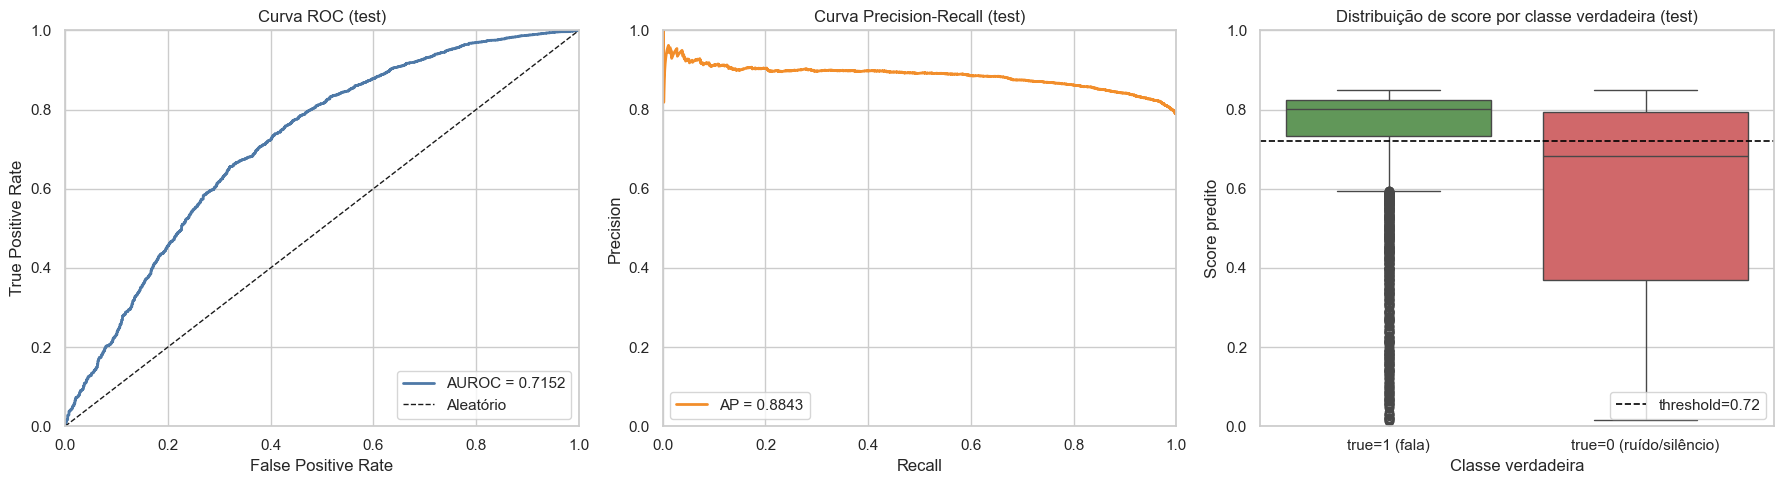

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

sns.set_theme(style='whitegrid')

# Ajuste este limiar conforme sua estratégia operacional
SCORE_THRESHOLD = 0.72

# Usamos o split de teste para análise final de discriminação
preds_test, scores_test = infer_records(
    model,
    pack_test.X,
    batch_size=int(best['batch_size']),
    threshold=SCORE_THRESHOLD,
    device=DEVICE,
)
y_test = pack_test.y

# Curvas ROC e PR
fpr, tpr, _ = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, scores_test)
ap = average_precision_score(y_test, scores_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) ROC
ax = axes[0]
ax.plot(fpr, tpr, color='#4e79a7', linewidth=2, label=f'AUROC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
ax.set_title('Curva ROC (test)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='lower right')

# 2) Precision-Recall
ax = axes[1]
ax.plot(recall, precision, color='#f28e2b', linewidth=2, label=f'AP = {ap:.4f}')
ax.set_title('Curva Precision-Recall (test)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='lower left')

# 3) Boxplot de score por classe verdadeira (preds vs true via score)
ax = axes[2]
df_box = pd.DataFrame({
    'true_label': y_test,
    'pred_score': scores_test,
})
df_box['true_label'] = df_box['true_label'].map({0: 'true=0 (ruído/silêncio)', 1: 'true=1 (fala)'})

sns.boxplot(
    data=df_box,
    x='true_label',
    y='pred_score',
    hue='true_label',
    legend=False,
    palette=['#59a14f', '#e15759'],
    ax=ax,
)
ax.axhline(SCORE_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'threshold={SCORE_THRESHOLD:.2f}')
ax.set_title('Distribuição de score por classe verdadeira (test)')
ax.set_xlabel('Classe verdadeira')
ax.set_ylabel('Score predito')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## 6. Exportar artefatos

In [ ]:

export_payload = {
    'best_params': {k: (float(v) if isinstance(v, (np.floating,)) else int(v) if isinstance(v, (np.integer,)) else v) for k, v in best.items()},
    'seq_len': SEQ_LEN,
    'score_threshold': SCORE_THRESHOLD,
    'feature_count': len(feature_cols),
    'metrics': metrics_all,
}

with open(ARTIFACTS_DIR / 'metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(export_payload, f, indent=2)

with open(ARTIFACTS_DIR / 'best_params.json', 'w', encoding='utf-8') as f:
    json.dump(best, f, indent=2)

df_metrics.to_csv(ARTIFACTS_DIR / 'metrics_summary.csv', index=False)

print('Modelo salvo em:', MODEL_PATH)
print('Métricas salvas em:', ARTIFACTS_DIR / 'metrics_summary.json')

Modelo salvo em: results\lstm_asr\lstm_asr_best.pt
Métricas salvas em: results\lstm_asr\metrics_summary.json
